# Pricing Strategy Analysis (Car Prices)

## Objective
Analyze how car features (age, mileage, condition) affect selling price and identify pricing patterns.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
df = pd.read_csv('car_prices.csv')
df.head()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


The dataset is loaded to explore its structure and understand available features.

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          548536 non-null  object 
 2   model         548438 non-null  object 
 3   trim          548186 non-null  object 
 4   body          545642 non-null  object 
 5   transmission  493485 non-null  object 
 6   vin           558833 non-null  object 
 7   state         558837 non-null  object 
 8   condition     547017 non-null  float64
 9   odometer      558743 non-null  float64
 10  color         558088 non-null  object 
 11  interior      558088 non-null  object 
 12  seller        558837 non-null  object 
 13  mmr           558799 non-null  float64
 14  sellingprice  558825 non-null  float64
 15  saledate      558825 non-null  object 
dtypes: float64(4), int64(1), object(11)
memory usage: 68.2+ MB


In [22]:
df.describe()

,year,condition,odometer,mmr,sellingprice
count,558837.000000,547017.000000,558743.000000,558799.000000,558825.000000
mean,2010.038927,30.672365,68320.017767,13769.377495,13611.358810
std,3.966864,13.402832,53398.542821,9679.967174,9749.501628
min,1982.000000,1.000000,1.000000,25.000000,1.000000
25%,2007.000000,23.000000,28371.000000,7100.000000,6900.000000
50%,2012.000000,35.000000,52254.000000,12250.000000,12100.000000
75%,2013.000000,42.000000,99109.000000,18300.000000,18200.000000
max,2015.000000,49.000000,999999.000000,182000.000000,230000.000000


In [40]:
df.columns

Index(['year', 'make', 'model', 'trim', 'body', 'transmission', 'vin', 'state',
       'condition', 'odometer', 'color', 'interior', 'seller', 'mmr',
       'sellingprice', 'saledate', 'car_age', 'price_diff'],
      dtype='object')

- Checked data types and missing values
- Observed numerical and categorical columns
- Identified key variables like selling price, mileage, and condition

In [23]:
df.isnull().sum()

,0
year,0
make,10301
model,10399
trim,10651
body,13195
transmission,65352
vin,4
state,0
condition,11820
odometer,94


In [24]:
df.dropna(inplace=True)

Missing values were removed to ensure data consistency.

In [25]:
df['sellingprice'] = pd.to_numeric(df['sellingprice'], errors='coerce')

In [26]:
df['odometer'] = pd.to_numeric(df['odometer'], errors='coerce')

In [33]:
df['saledate'].head()

,saledate
0,2014-12-16 12:30:00+08:00
1,2014-12-16 12:30:00+08:00
2,2015-01-15 04:30:00+08:00
3,2015-01-29 04:30:00+08:00
4,2014-12-18 12:30:00+08:00


In [35]:
df['saledate'] = pd.to_datetime(
    df['saledate'],
    format='%Y-%m-%d %H:%M:%S',
    errors='coerce'
)

In [36]:
df['saledate'].head()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 472325 entries, 0 to 558836
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype                                 
---  ------        --------------   -----                                 
 0   year          472325 non-null  int64                                 
 1   make          472325 non-null  object                                
 2   model         472325 non-null  object                                
 3   trim          472325 non-null  object                                
 4   body          472325 non-null  object                                
 5   transmission  472325 non-null  object                                
 6   vin           472325 non-null  object                                
 7   state         472325 non-null  object                                
 8   condition     472325 non-null  float64                               
 9   odometer      472325 non-null  float64                          

The 'saledate' column was converted into datetime format for time-based analysis.

In [28]:
df['car_age'] = 2024 - df['year']

In [29]:
df['price_diff'] = df['sellingprice'] - df['mmr']

- Car age helps analyze depreciation
- Price difference helps identify overpricing or underpricing

##Exploratory Data Analysis

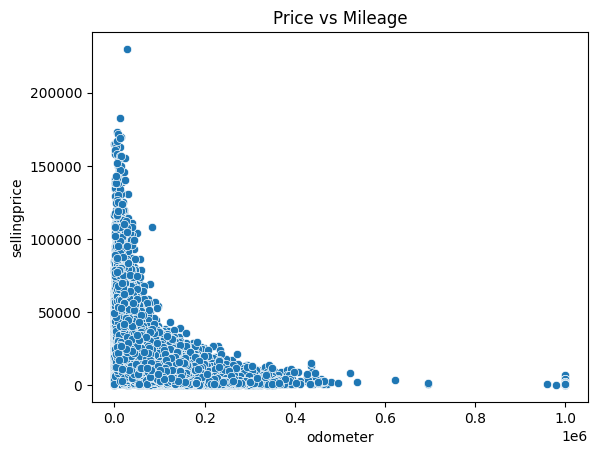

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x='odometer', y='sellingprice', data=df)
plt.title("Price vs Mileage")

plt.savefig('price_vs_mileage.png')
plt.show()

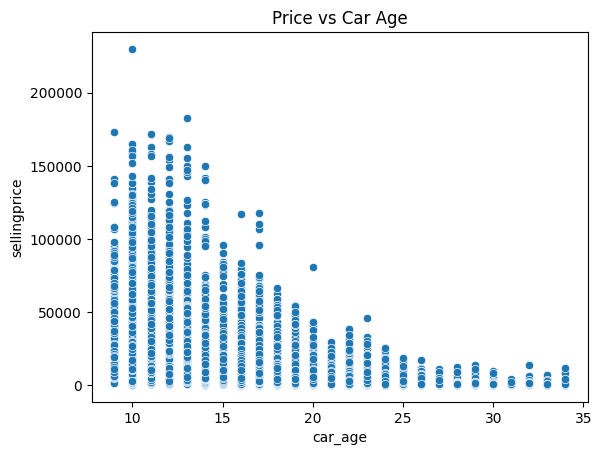

In [31]:
sns.scatterplot(x='car_age', y='sellingprice', data=df)
plt.title("Price vs Car Age")

plt.savefig('price_vs_age.png')
plt.show()

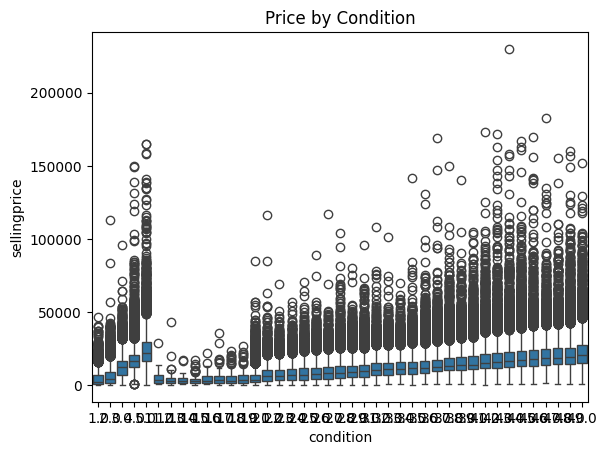

In [32]:
sns.boxplot(x='condition', y='sellingprice', data=df)
plt.title("Price by Condition")

plt.savefig('price_by_condition.png')
plt.show()

In [37]:
df.groupby('make')['sellingprice'].mean().sort_values(ascending=False).head(10)

,sellingprice
make,
Rolls-Royce,153456.250000
Ferrari,128852.941176
Lamborghini,111500.000000
Bentley,72713.333333
Tesla,67054.347826
Aston Martin,55500.000000
Fisker,46461.111111
Maserati,43729.816514
Lotus,40800.000000


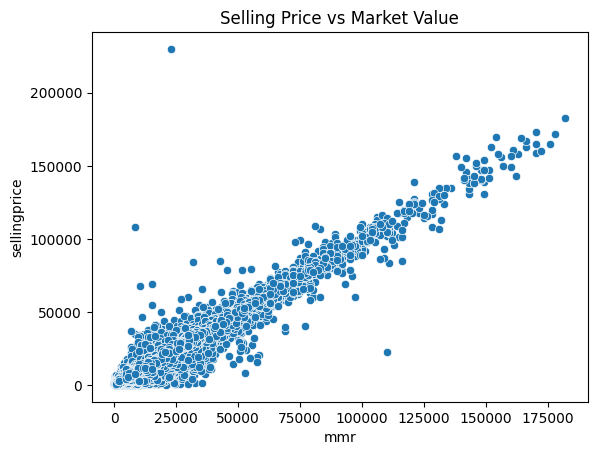

In [38]:
sns.scatterplot(x='mmr', y='sellingprice', data=df)
plt.title("Selling Price vs Market Value")

plt.savefig('price_vs_mmr.png')
plt.show()

In [39]:
df[['sellingprice','odometer','car_age','mmr']].corr()

,sellingprice,odometer,car_age,mmr
sellingprice,1.000000,-0.577397,-0.578933,0.983493
odometer,-0.577397,1.000000,0.773102,-0.582654
car_age,-0.578933,0.773102,1.000000,-0.588614
mmr,0.983493,-0.582654,-0.588614,1.000000


Correlation analysis helps identify relationships between numerical variables affecting price.

## Key Insights

- Selling price decreases as mileage increases
- Older cars tend to have lower resale value
- Cars in better condition are priced higher
- Selling price closely follows market value (MMR)
- Some vehicles are overpriced compared to market benchmarks

## Conclusion

The analysis shows that car pricing is strongly influenced by mileage, age, condition, and market benchmarks. Understanding these factors can help optimize pricing strategies and improve sales outcomes.